<a href="https://colab.research.google.com/github/tacinunesc/Aula_1_Gemeos_Digitais_UniFacens/blob/main/aula1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning na Prática**

Previsão de Churn de Clientes

Fluxo do projeto:


*   Explorar dados
*   Preparar dador
*   Treinar modelo
*   Avaliar desempenho





In [1]:
import pandas as pd # Para manipulação e análise de dados, especialmente com DataFrames.
import numpy as np # Para operações numéricas e computação com arrays.
import matplotlib.pyplot as plt # Para criar visualizações e gráficos.
import seaborn as sns # Para criar gráficos estatísticos mais atraentes.
from sklearn.model_selection import train_test_split # Para dividir os dados em conjuntos de treinamento e teste.
from sklearn.preprocessing import StandardScaler # Para escalar os dados.
from sklearn.linear_model import LogisticRegression # O modelo de aprendizado de máquina (regressão logística).
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Para avaliar o desempenho do modelo.

# Inserção do Dataset

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [7]:
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head() # pd.read ler o ardquivo e head mostra as 5 primeiras linhas

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Questionamento

**O que cada linha representa?**

In [8]:
df.shape
df.info() #mostra as linhas e colunas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Questionamentos

*   Quantos clientes temos?
*   Quantas variáveis?
*   Quais tipos?

**Agora vamos vizualizar quantos dados tempo para Sim e Não**





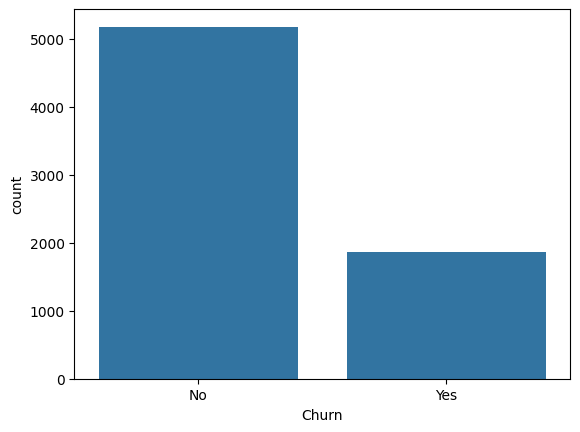

In [12]:
sns.countplot(x='Churn', data=df) # Cria um gráfico de contagem para a coluna 'Churn' do DataFrame 'df'
plt.show() # Exibe o gráfico

# Questionamento

Tem mais clientes que cancelam ou que permanecem?

*Selecionando dado para realização da análise*

In [13]:
df = df.drop('customerID', axis=1) # remove o idenficador dos clientes para que o ID não atrapalhe a analise
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})#atribui numeros ao SIM ou NAO, assim, 1-cancelou e 0 nao cancelou
df = pd.get_dummies(df, drop_first=True) # trasforma as variaveis categoricas em variaveis binárias

**Tarefa:**
Compare o dataframe antes e depois da aplicação de get_dummies.

Dica, utilize:
df.columns
df.shape


1. O número de colunas aumentou ou diminuiu?


2. Foram criadas novas colunas?


3. Quais são os nomes dessas colunas novas?


4. Observe o padrão dos nomes das novas colunas.

Exemplo típico:
Contract_Two year
InternetService_Fiber optic
PaymentMethod_Electronic check

O que esses nomes representam?


5. Analise os valores dentro dessas colunas.


Dica, utilize:
df[['Contract_Two year']].head()

Que valores aparecem nessas colunas?

O que significa 0 e 1?


6. Reflexão final:

**Reflita:**

Por que precisamos transformar variáveis categóricas em colunas numéricas antes de treinar um modelo de Machine Learning?


*Dica para exploração adicional*

Tente identificar uma coluna categórica do dataset original (por exemplo Contract) e ver como ela foi representada após o get_dummies.

In [14]:
X = df.drop('Churn', axis=1) # Cria uma nova variável X
y = df['Churn'] # Cria uma nova variável y

# Separa o problema de aprendizado em duas partes: Tipo Conteúdo X variáveis que explicam o problema e y variável que queremos prever

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #divide o conjunto de dados em quatro partes

## Questionamento

Qual a porcentagem de treinamento e de teste?
Qual o risco de utilizar 100% dos dados para treinamento?

In [18]:
scaler = StandardScaler() # Cria um objeto StandardScaler
X_train = scaler.fit_transform(X_train) # Transforma os dados de treinamento
X_test = scaler.transform(X_test) # Transforma os dados de teste


# Normalizando variáveis

In [21]:
model = LogisticRegression(max_iter=1000) # Cria um objeto LogisticRegression
model.fit(X_train, y_train) # Treina o modelo com os dados de treinamento

LogisticRegression(max_iter=1000)

**Pergunta**:
O que representa o argumento max_iter=1000.

In [22]:
y_pred = model.predict(X_test) # Faz previsões com o modelo treinado
accuracy_score(y_test, y_pred) # Calcula a acurácia das previsões


0.7842441447835344

Aqui temos a acurácia do modelo, note que estamos comparando o teste (y_test) com os valores previstos (y_pred), a variável y_pred é obtida pelo model.predict() com os dados de teste (X_test).

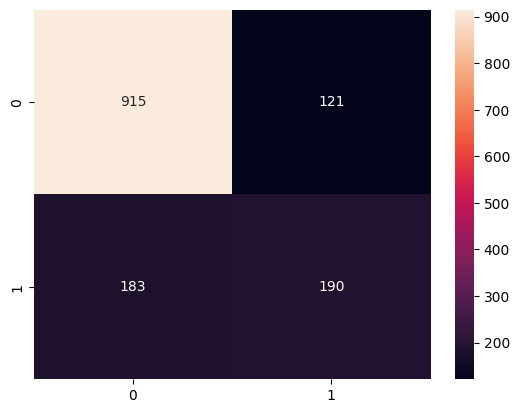

In [23]:
cm = confusion_matrix(y_test, y_pred) # Cria uma matriz de confusão
sns.heatmap(cm, annot=True, fmt='d') # Cria um mapa de calor da matriz de conf
plt.show() # Exibe o gráfico

# Já rodou o modelo agora vai calcular:



*   Calcule a precisão (% de acerto da classe, quantos sim ou não realmente acertou)
*   Calcule o recall (% de acertos dos casos, clinetes que cancelaram ou não)
*   Calcule F1-score (média harmônica entre precisão e recall)





In [24]:
print(classification_report(y_test, y_pred)) # Imprime um relatório de classificação

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1036
           1       0.61      0.51      0.56       373

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409

